In [1]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
train_df = pd.read_csv("../data/train_clean.csv")
test_df = pd.read_csv("../data/test_clean.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (835, 5)
Test: (150, 3)


In [3]:
le = LabelEncoder()

y_train = le.fit_transform(train_df["Genre"])
y_test = le.transform(test_df["Genre"])

print(le.classes_)

['Affection' 'Death' 'Environment' 'Music']


In [4]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train = tfidf.fit_transform(
    train_df["clean_poem"]
)

X_test = tfidf.transform(
    test_df["clean_poem"]
)

print(X_train.shape)
print(X_test.shape)

(835, 5000)
(150, 5000)


In [5]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:")
print(accuracy_score(y_test, y_pred_nb))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy:
0.13333333333333333

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.02      0.04       100
           1       0.04      0.15      0.07        13
           2       0.26      0.48      0.33        25
           3       0.08      0.33      0.12        12

    accuracy                           0.13       150
   macro avg       0.34      0.25      0.14       150
weighted avg       0.72      0.13      0.10       150



In [6]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.22666666666666666

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.16      0.27       100
           1       0.07      0.23      0.11        13
           2       0.25      0.44      0.32        25
           3       0.08      0.33      0.13        12

    accuracy                           0.23       150
   macro avg       0.32      0.29      0.21       150
weighted avg       0.65      0.23      0.25       150



In [7]:
svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Linear SVM Accuracy:")
print(accuracy_score(y_test, y_pred_svm))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy:
0.24666666666666667

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.21      0.34       100
           1       0.08      0.23      0.12        13
           2       0.21      0.40      0.27        25
           3       0.07      0.25      0.11        12

    accuracy                           0.25       150
   macro avg       0.31      0.27      0.21       150
weighted avg       0.63      0.25      0.29       150



In [8]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy
2,Linear SVM,0.246667
1,Logistic Regression,0.226667
0,Naive Bayes,0.133333


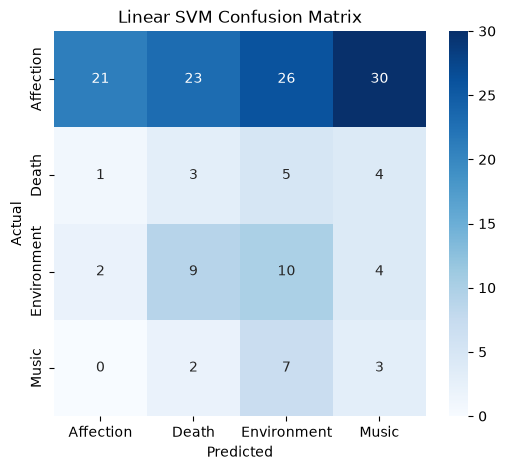

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM Confusion Matrix")

plt.show()

In [10]:
print(train_df.shape)
print(test_df.shape)

print("\nTRAIN")
print(train_df["Genre"].value_counts())

print("\nTEST")
print(test_df["Genre"].value_counts())

(835, 5)
(150, 3)

TRAIN
Genre
Music          238
Death          229
Environment    227
Affection      141
Name: count, dtype: int64

TEST
Genre
Affection      100
Environment     25
Death           13
Music           12
Name: count, dtype: int64


In [11]:
print(train_df["Genre"].head(20))
print(train_df["Genre"].tail(20))

print(test_df["Genre"].head(20))
print(test_df["Genre"].tail(20))

0     Music
1     Music
2     Music
3     Music
4     Music
5     Music
6     Music
7     Music
8     Music
9     Music
10    Music
11    Music
12    Music
13    Music
14    Music
15    Music
16    Music
17    Music
18    Music
19    Music
Name: Genre, dtype: str
815    Environment
816    Environment
817    Environment
818    Environment
819    Environment
820    Environment
821    Environment
822    Environment
823    Environment
824    Environment
825    Environment
826    Environment
827    Environment
828    Environment
829    Environment
830    Environment
831    Environment
832    Environment
833    Environment
834    Environment
Name: Genre, dtype: str
0     Music
1     Music
2     Music
3     Music
4     Music
5     Music
6     Music
7     Music
8     Music
9     Music
10    Music
11    Music
12    Death
13    Death
14    Death
15    Death
16    Death
17    Death
18    Death
19    Death
Name: Genre, dtype: str
130    Environment
131    Environment
132    Environment
133    Envi

In [13]:
full_df = pd.concat([train_df, test_df], ignore_index=True)

In [14]:
from sklearn.model_selection import train_test_split

X = full_df["clean_poem"]
y = full_df["Genre"]

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train_text.shape)
print(X_test_text.shape)

(788,)
(197,)


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train_text)
y_test = le.transform(y_test_text)

print(le.classes_)

['Affection' 'Death' 'Environment' 'Music']


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,3),
    min_df=1,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print(X_train.shape)
print(X_test.shape)

(788, 10000)
(197, 10000)


In [22]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_acc = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes:", nb_acc)

Naive Bayes: 0.3604060913705584


In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression:", lr_acc)

Logistic Regression: 0.38071065989847713


In [24]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)

print("Linear SVM:", svm_acc)

Linear SVM: 0.37055837563451777


In [25]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        nb_acc,
        lr_acc,
        svm_acc
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Logistic Regression,0.380711
2,Linear SVM,0.370558
0,Naive Bayes,0.360406


In [26]:
import joblib

joblib.dump(tfidf, "tfidf.pkl")
joblib.dump(lr, "logistic_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']